In [76]:
import sys
sys.path.insert(0, '..')

In [77]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import interpax as ipx


In [78]:
objs = [
    "HD-139664",
    "HD109085",
    "GJ784-PSF",
    "PSF-5-K0",
    "GSC8056-0482",
    "GSC8491-1194",
    "GSC8894-0426",
    "HIP10679",
    "HIP107947",
    "HIP109901",
    "HIP112312A",
    "HIP112312B",
    "HIP114530",
    "HIP118008",
    "HIP12413",
    "HIP12545",
    "HIP12787B",
    "HIP17695",
    "HIP18859",
    "HIP19335",
    "HIP1993",
    "HIP21547",
    "HIP21632",
    "HIP23309",
    "HIP26990",
    "HIP2729",
    "HIP36627",
    "HIP37766",
    "HIP39896B",
    "HIP41889",
    "HIP50156",
    "HIP56445",
    "HIP6485",
    "HIP77199",
    "HIP9892",
    "HIP9902",
    "SSS1102-34",
    "TWA12",
    "TWA23",
    "TYC5672-0216",
    "G238-44",
]

In [79]:
wid = 80
oversample = 4

nwavels = 20
npoly=6

n_modes = 15
n_zernikes = 30

resolved_wid = 1

optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

vects = np.load("../data/iterative_spectrum_basis_F110W.npy")[:,:npoly]
assert vects.shape == (nwavels, npoly)
spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))




exposures_single = [
    exposure_from_file(ddir + 'n8zu81fbq_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F110W"), crop=wid),
    # exposure_from_file(ddir + 'n8zu81fcq_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F110W"), crop=wid),
]


159.962 5.4
Version 4.1.1
31.1289


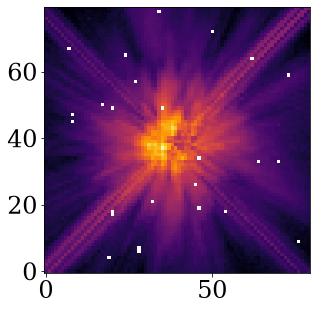

In [80]:
plt.imshow(exposures_single[0].data**0.125)

In [81]:
exposures_single[0].target

'PSF-1-M0'

In [82]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},
    "primary_rot": {},

    "bias": {},
    "occulter_radius": 0.7,
    "occulter_coeffs": np.zeros(2)+1,
    "fnumber": 45.7,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*4)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.03869419,  0.03731998])*0.
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0.2167105 , -0.17420508])#*0.

    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.array([160.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.array([13.,10.]) #np.asarray([-13.,-7.])#
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 0.#-90.
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = 0.##-90.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

35.75537400864431


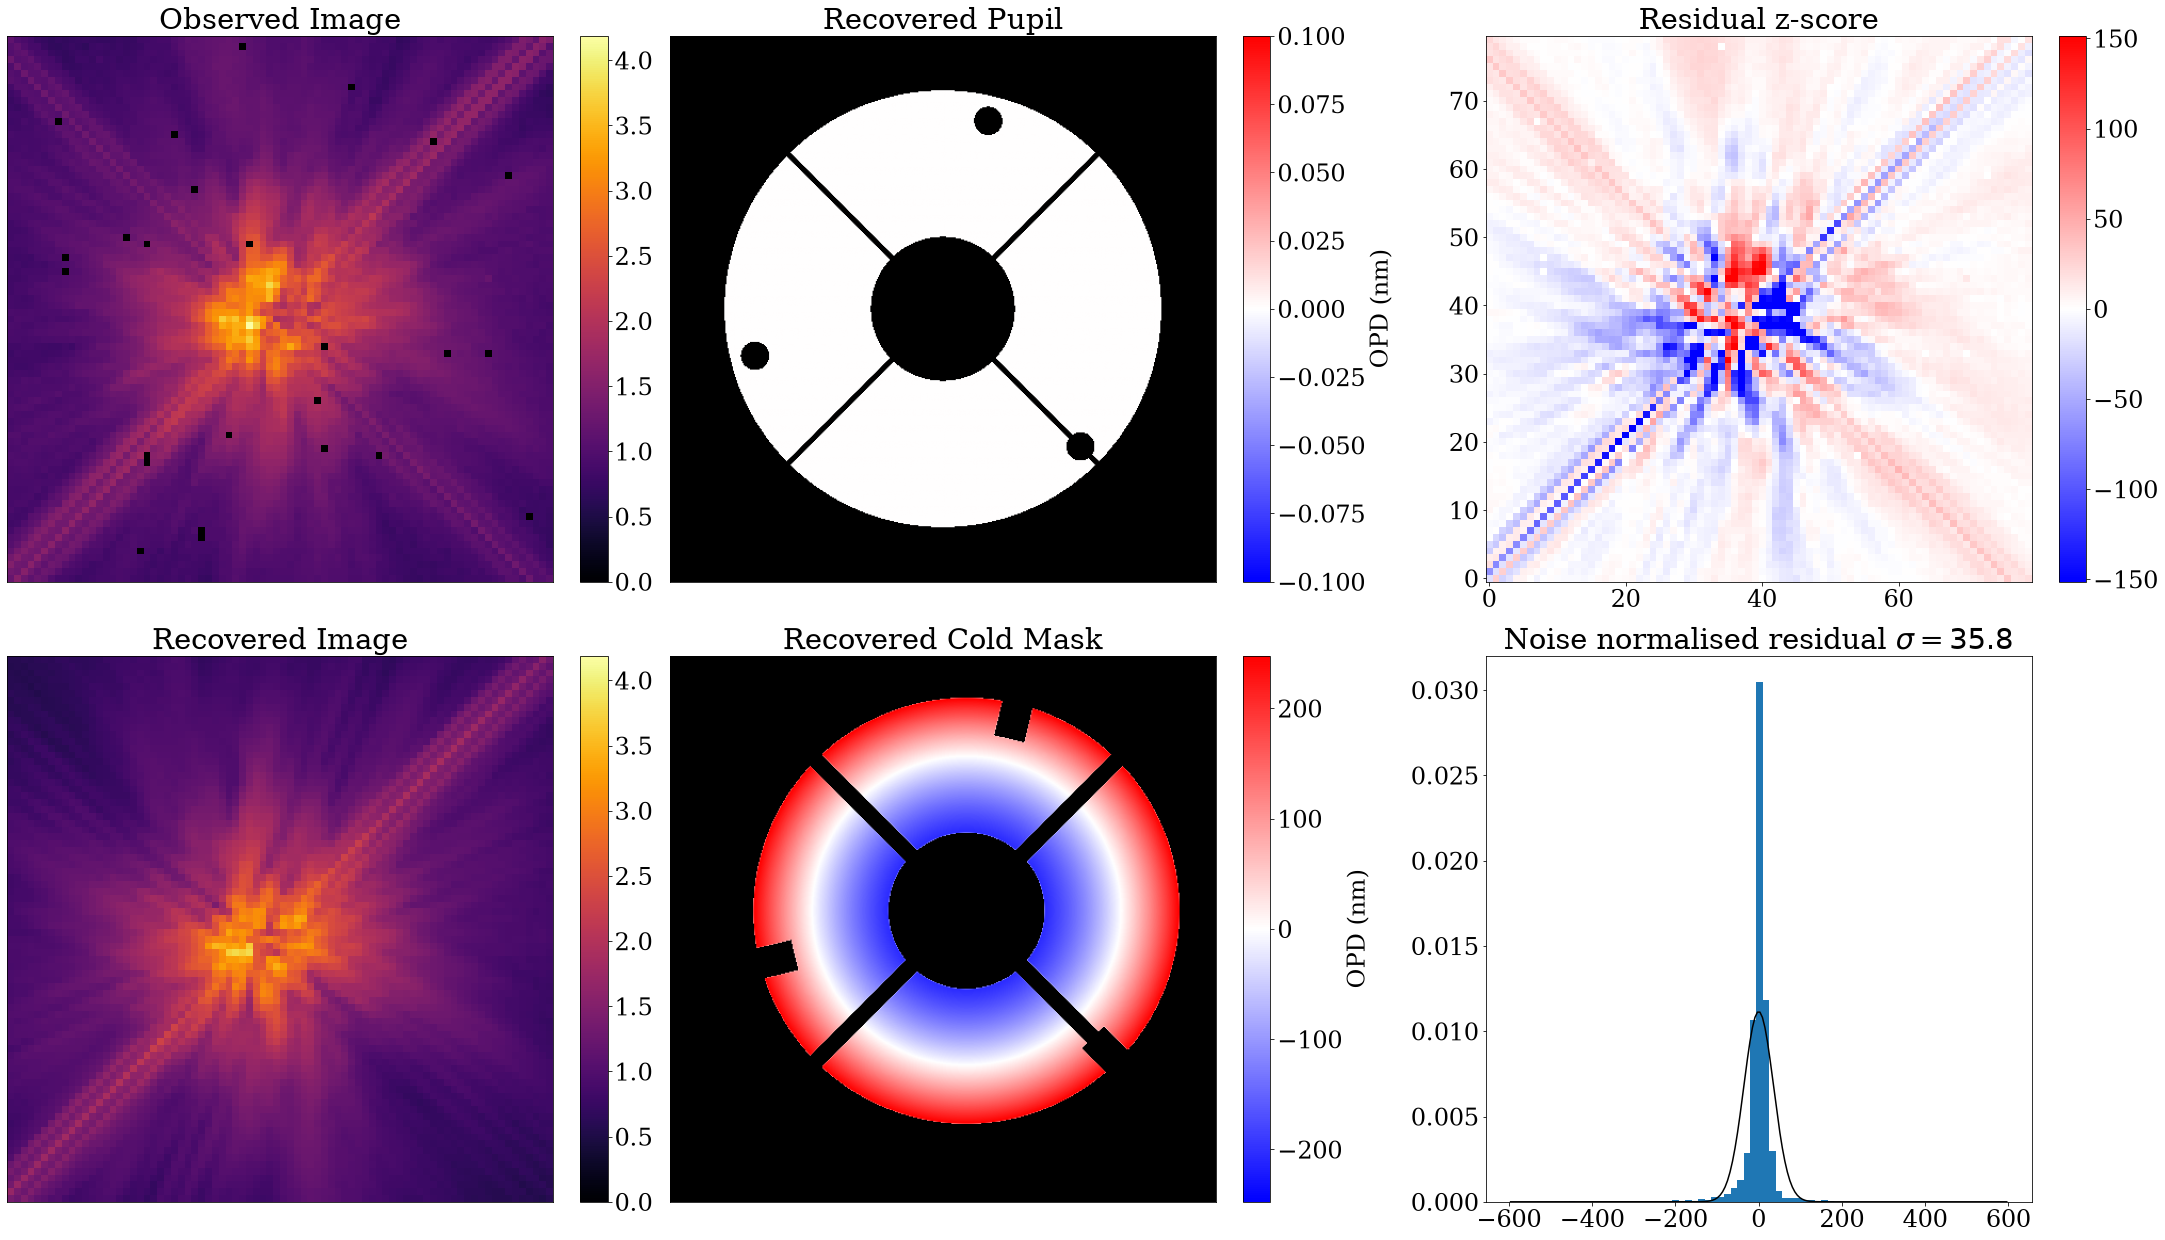

In [83]:
plot_comparison(model_single, params, exposures_single, percentile=99, wf_size=512)

In [84]:
g = 5e-2

"""
    "spectrum": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*20, 40),
    
    "bias": sgd(g*3, 20),
    "primary_opd": sgd(g*0.1, 10),
    # "primary_opd": adam(0.1, 10),

    "cold_mask_opd": sgd(g*3, 10),

    "primary_tilt": sgd(g*1, 10),
    "cold_mask_tilt": sgd(g*1, 10),
    #"jitter": opt(g*1, 120),


    "cold_mask_shear": sgd(g*2, 200),
    "cold_mask_rot": sgd(g*3, 200),
    "cold_mask_scale": sgd(g*15, 200),

    # "quadrature": sgd(g*20, 400)

    "occulter_radius": sgd(g*10, 200),
    "fnumber": sgd(g*0.05, 220),

    "occulter_coeffs": sgd(g*20, 300),
"""

things = {
    "primary_opd": sgd(g*0.2, 0),


    "spectrum": sgd(g*3, 0),
    "primary_tilt": sgd(g*3, 0),
    "cold_mask_tilt": sgd(g*1, 0),
    "cold_mask_opd": sgd(g*1, 0),

    "bias": sgd(g*3, 50),
    "cold_mask_shift": sgd(g*1, 0),
    "primary_low": sgd(g*3, 0),

    "cold_mask_rot": sgd(g*1, 0),
    "primary_rot": sgd(g*1, 0),


    # "occulter_radius": sgd(g*3., 0),
    # "fnumber": sgd(g*2., 0),
}

things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*2, 15.),
    "cold_mask_tilt": sgd(g*1.5, 0),
    "cold_mask_opd": sgd(g*1, 40),

    "bias": sgd(g*3, 50),
    "cold_mask_shift": sgd(g*5, 70),
    "cold_mask_rot": sgd(g*10, 70),
    "primary_rot": sgd(g*10, 70),

    "primary_low": sgd(g*0.2, 90),

    # "cold_mask_scale": sgd(g*5, 120),
    # "cold_mask_shear": sgd(g*10, 120),

    # "occulter_radius": sgd(g*0.3, 150),
    # "occulter_coeffs": sgd(g*2, 200),
    # # "fnumber": sgd(g*2., 150),
}

groups = list(things.keys())

In [85]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [86]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things_start, 300,
    precond_method="gn_exact", precond_kwargs=dict(chunk=16))

  0%|          | 0/300 [00:00<?, ?it/s]

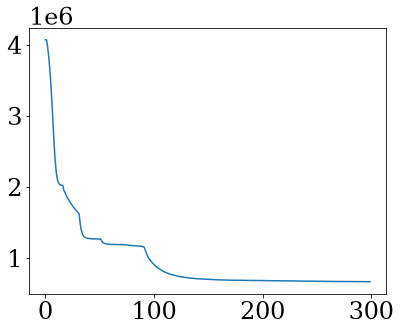

In [87]:
plt.plot(losses[:])

9
14.486210537806636


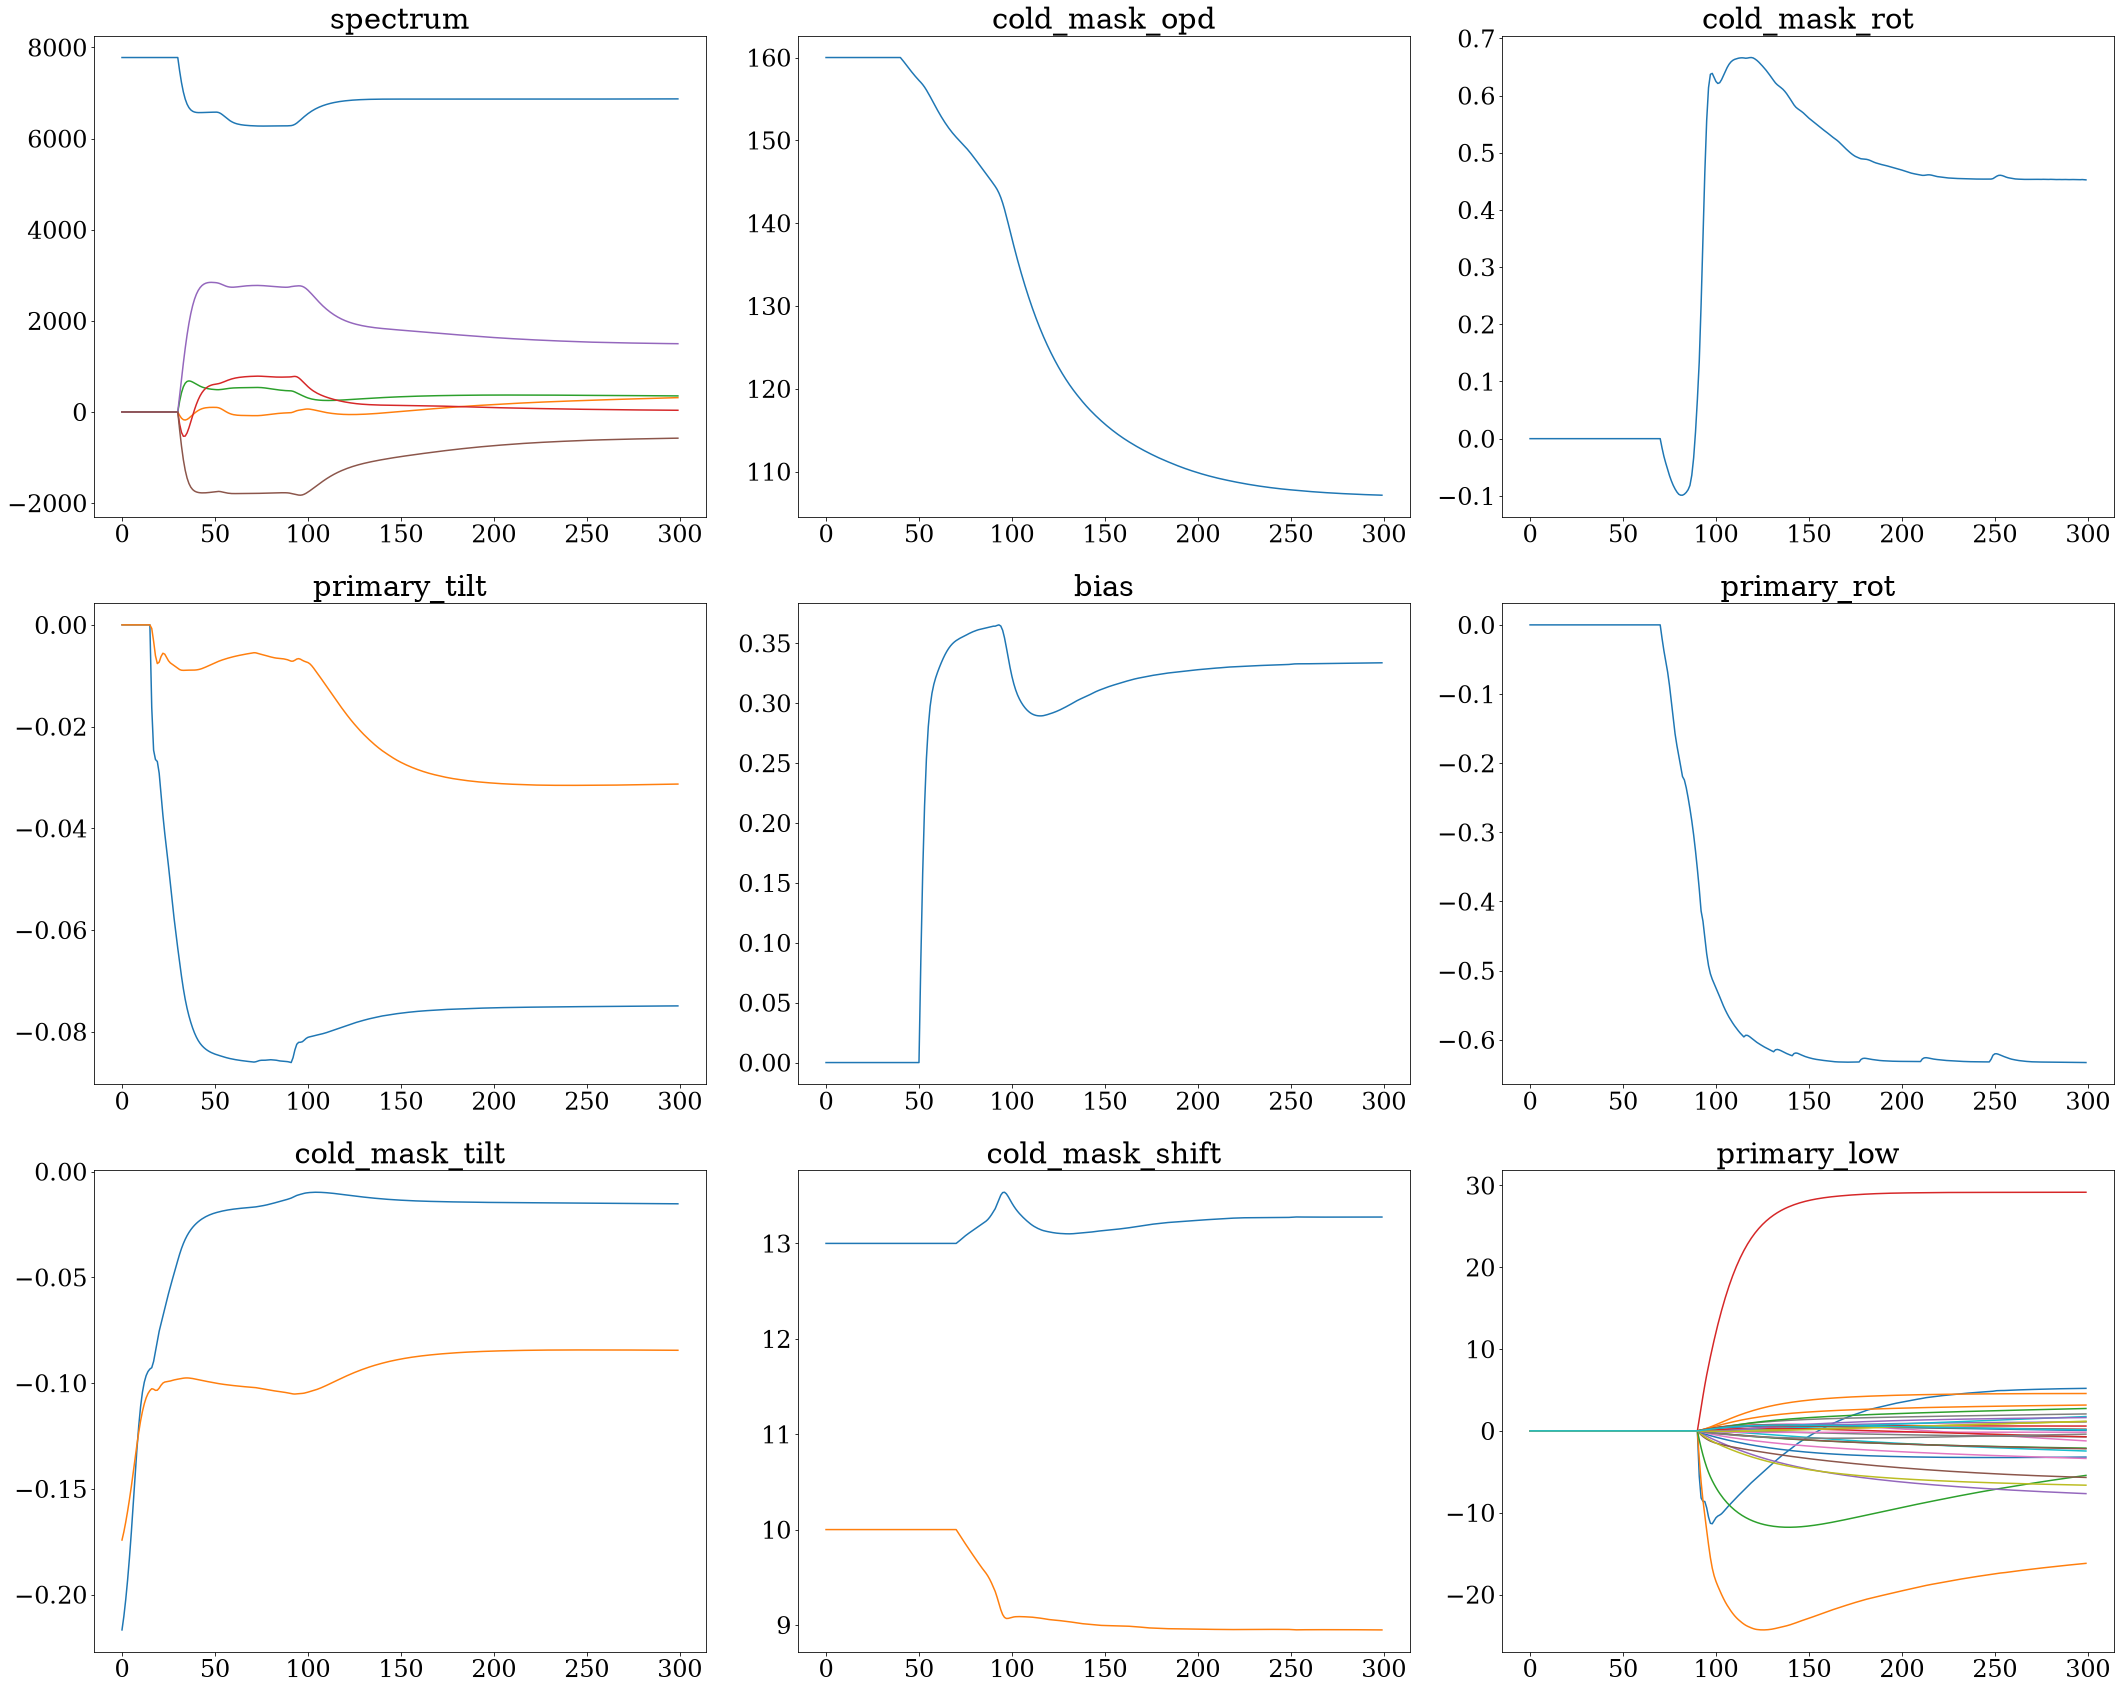

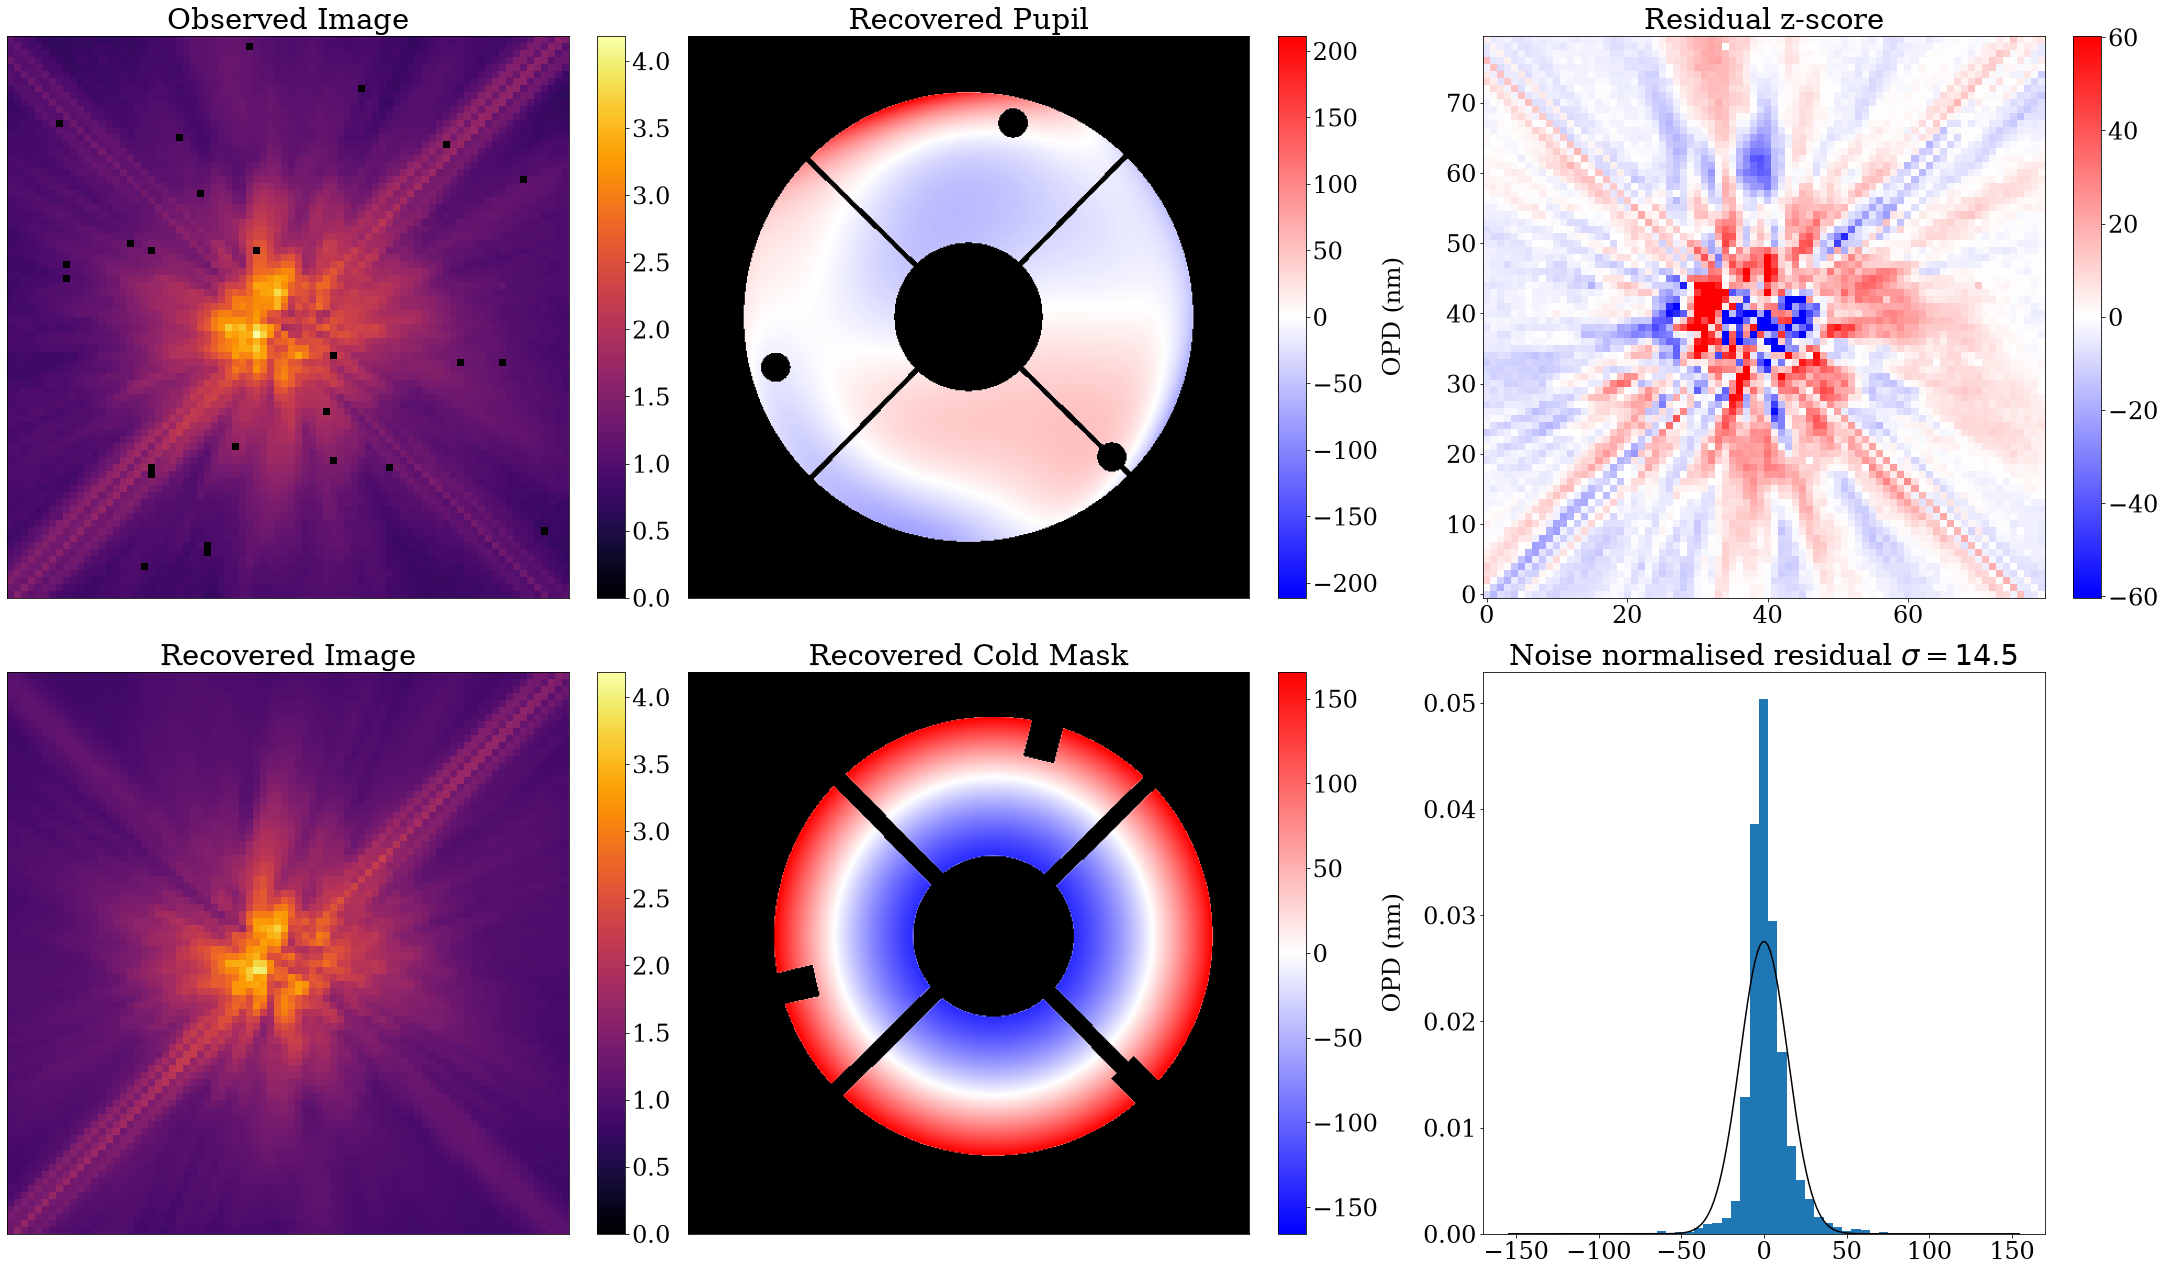

In [88]:
plot_params(params_history, list(things_start.keys()), xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, percentile=99, quadrature=False, wf_size=512)

In [89]:
dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)

Wavefront(
  phasor=c128[128,128], wavelength=f64[], pixel_scale=f64[], center=f64[1]
)

In [90]:
dlu.arcsec2rad(0.3)*24*2.4

8.37758040957278e-05

In [91]:
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

In [92]:
# testocculter = CLIMBOcculter(dlu.arcsec2rad(0.3)*24*2.4, np.zeros(1)+3e-3, np.zeros(1))
# final_optics.occulter.layers["occulter"]

In [93]:
# plt.imshow(np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=12e-6, npixels=32)).phasor))

In [94]:
# plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

In [95]:
params_history[-1]

{'bias': {'n8zu81fbq': Array(0.33368259, dtype=float64)},
 'cold_mask_opd': {'global': Array([107.140573], dtype=float64)},
 'cold_mask_rot': {'global': Array(0.4525682, dtype=float64)},
 'cold_mask_shift': {'global': Array([13.27635069,  8.94819299], dtype=float64)},
 'cold_mask_tilt': {'global': Array([-0.01523518, -0.08449137], dtype=float64)},
 'primary_low': {'n8zu81fbq': Array([  5.20040704, -16.19211733,  -5.44047892,  29.17356593,
          -7.66812285,  -5.68933139,  -1.22195564,  -0.73464279,
          -6.6370097 ,  -2.45895405,   0.05173375,   4.57043472,
          -2.10537749,   0.59247184,   1.09134927,  -2.18672448,
          -0.15996319,   2.07337593,   1.18179415,   1.75218359,
          -3.20193095,   3.15886859,   2.73812826,  -0.71182274,
           1.62844079,   0.21411888,  -3.36926257,  -0.39661353,
           1.13151816,   0.12581746], dtype=float64)},
 'primary_rot': {'global': Array(-0.63291919, dtype=float64)},
 'primary_tilt': {'n8zu81fbq': Array([-0.07493341

In [96]:
# stop

In [97]:
# Keep the stage-1 values of parameters that stage 2 does not fit (stage 2 injects into model_single)
model_single = ModelParams(params_history[-1]).inject(model_single)
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [98]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things, 200,
    precond_method="gn_probe", precond_kwargs=dict(n_probes=32))

  0%|          | 0/200 [00:00<?, ?it/s]

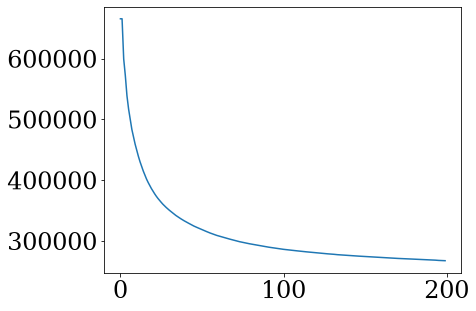

In [99]:
plt.plot(losses[:])

In [100]:
losses[-1]

Array(267434.33974392, dtype=float64)

10
9.296301197103897


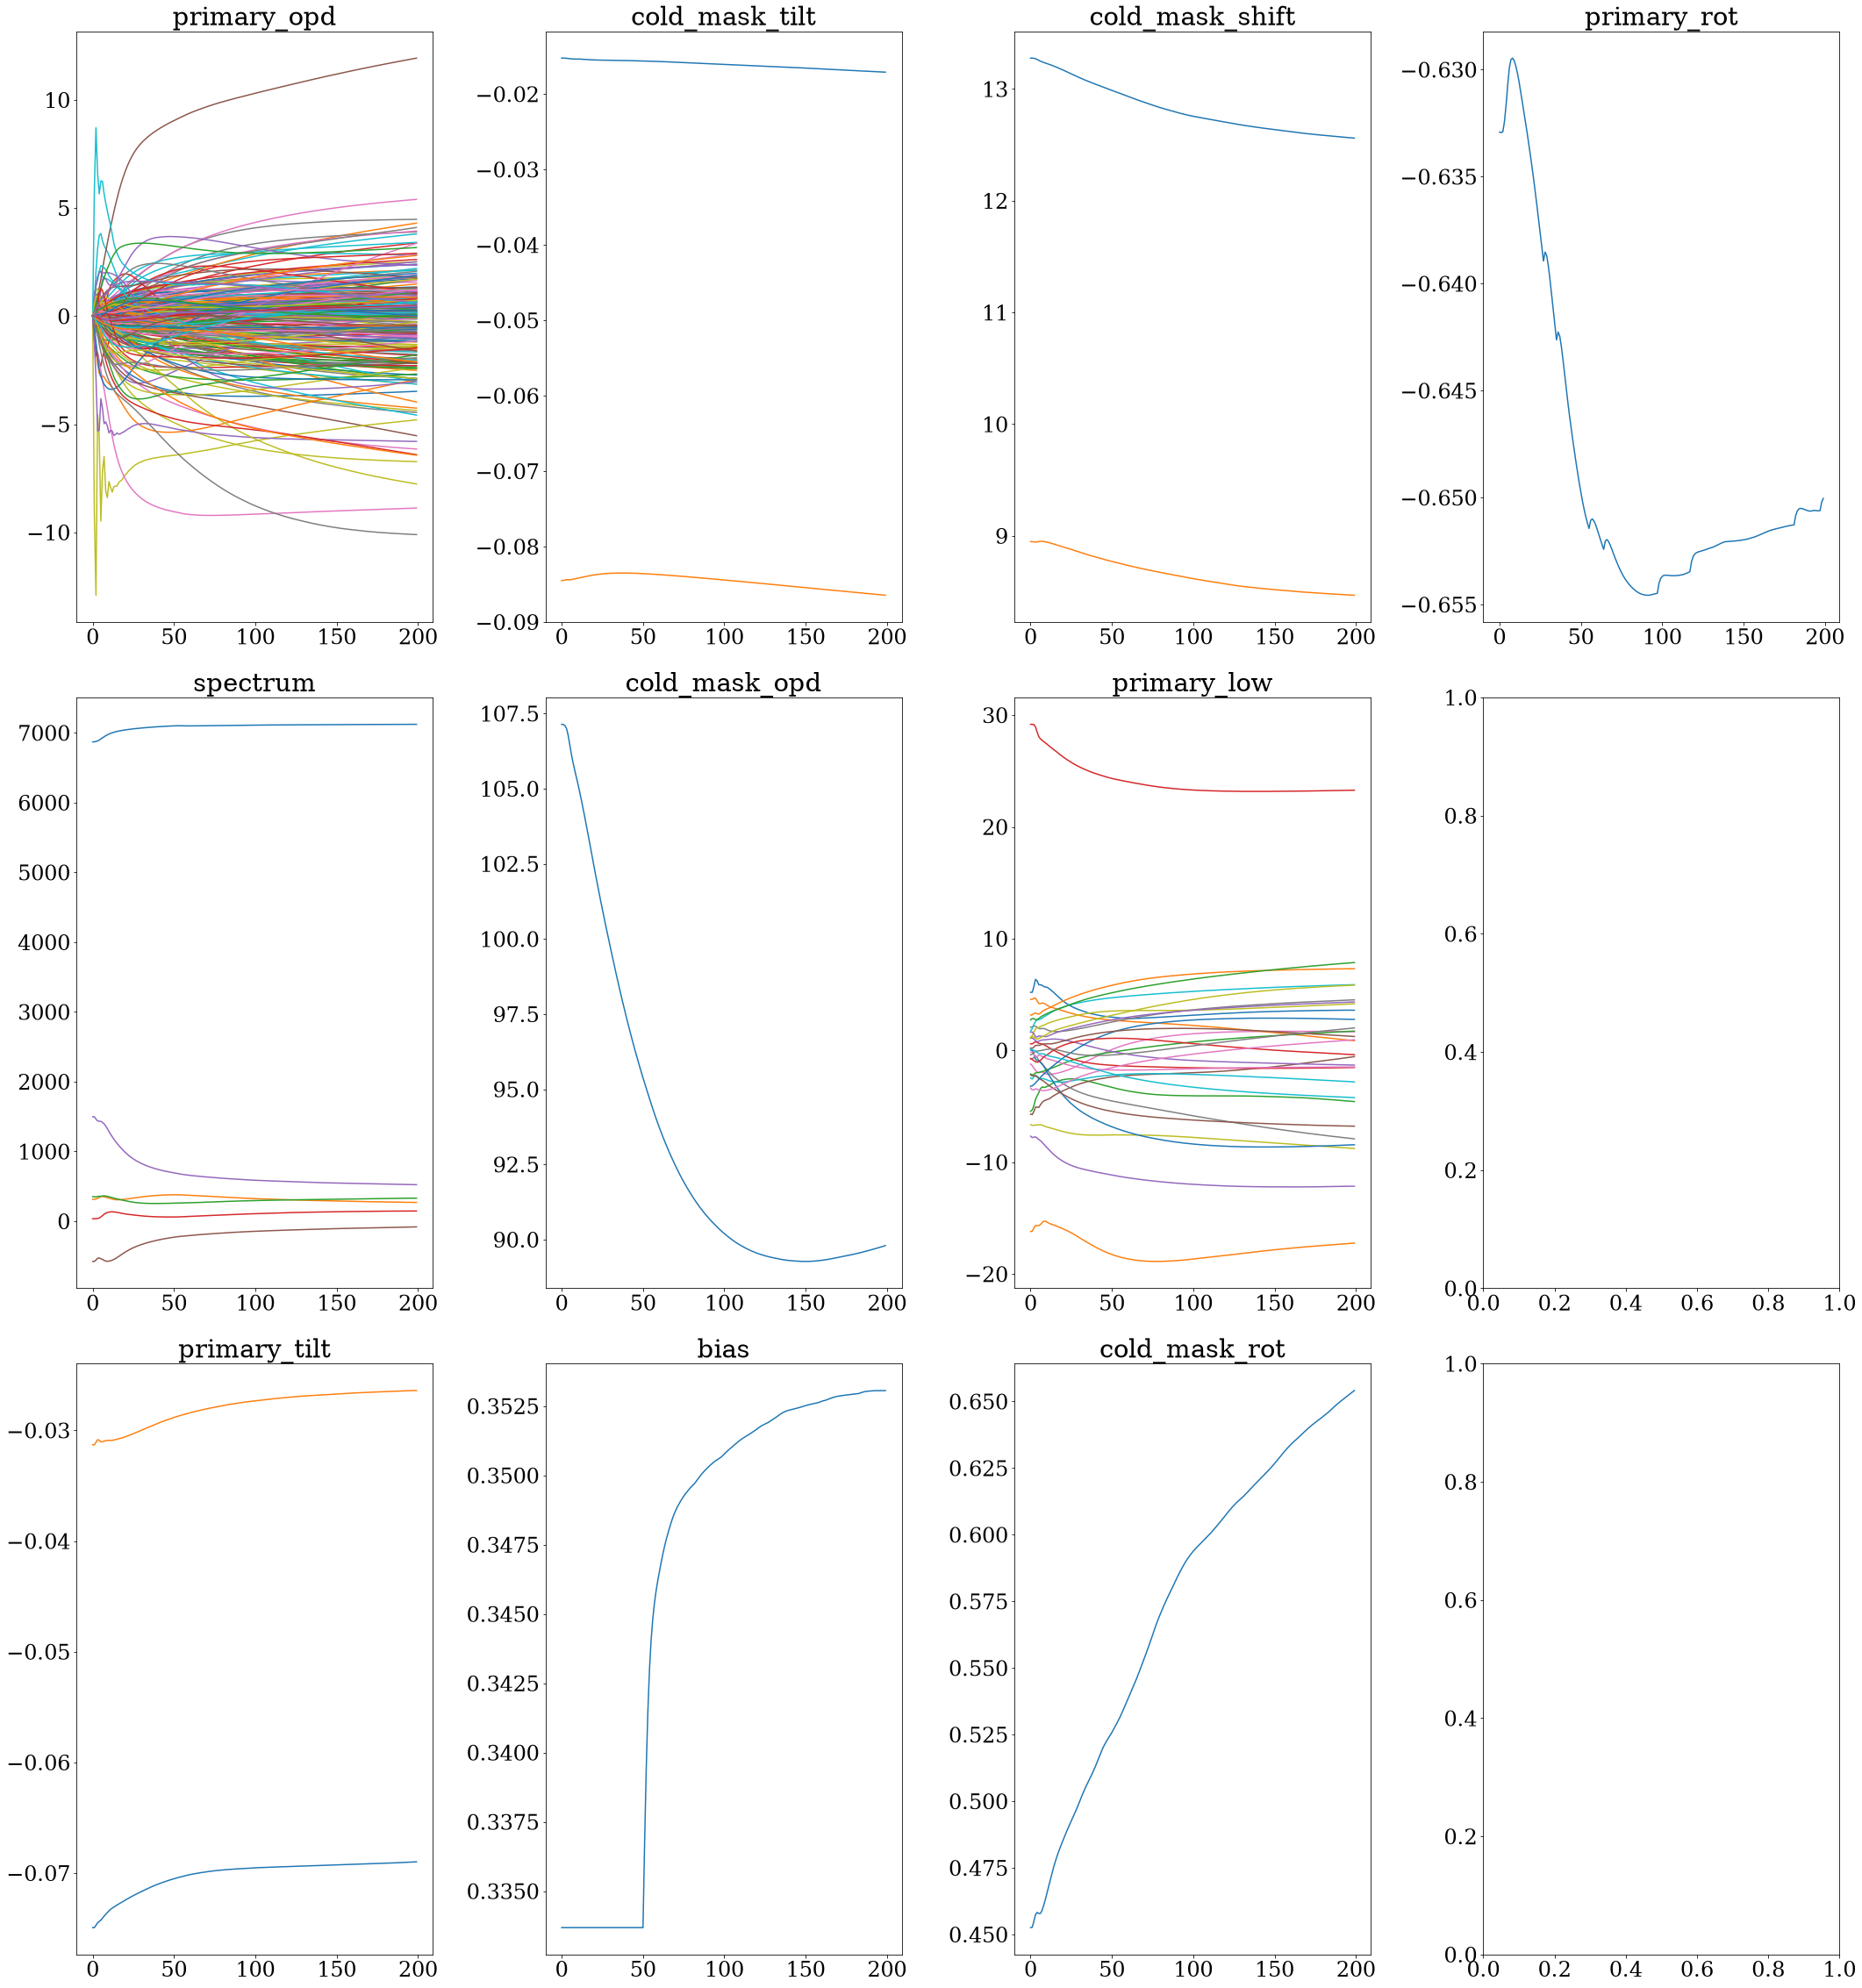

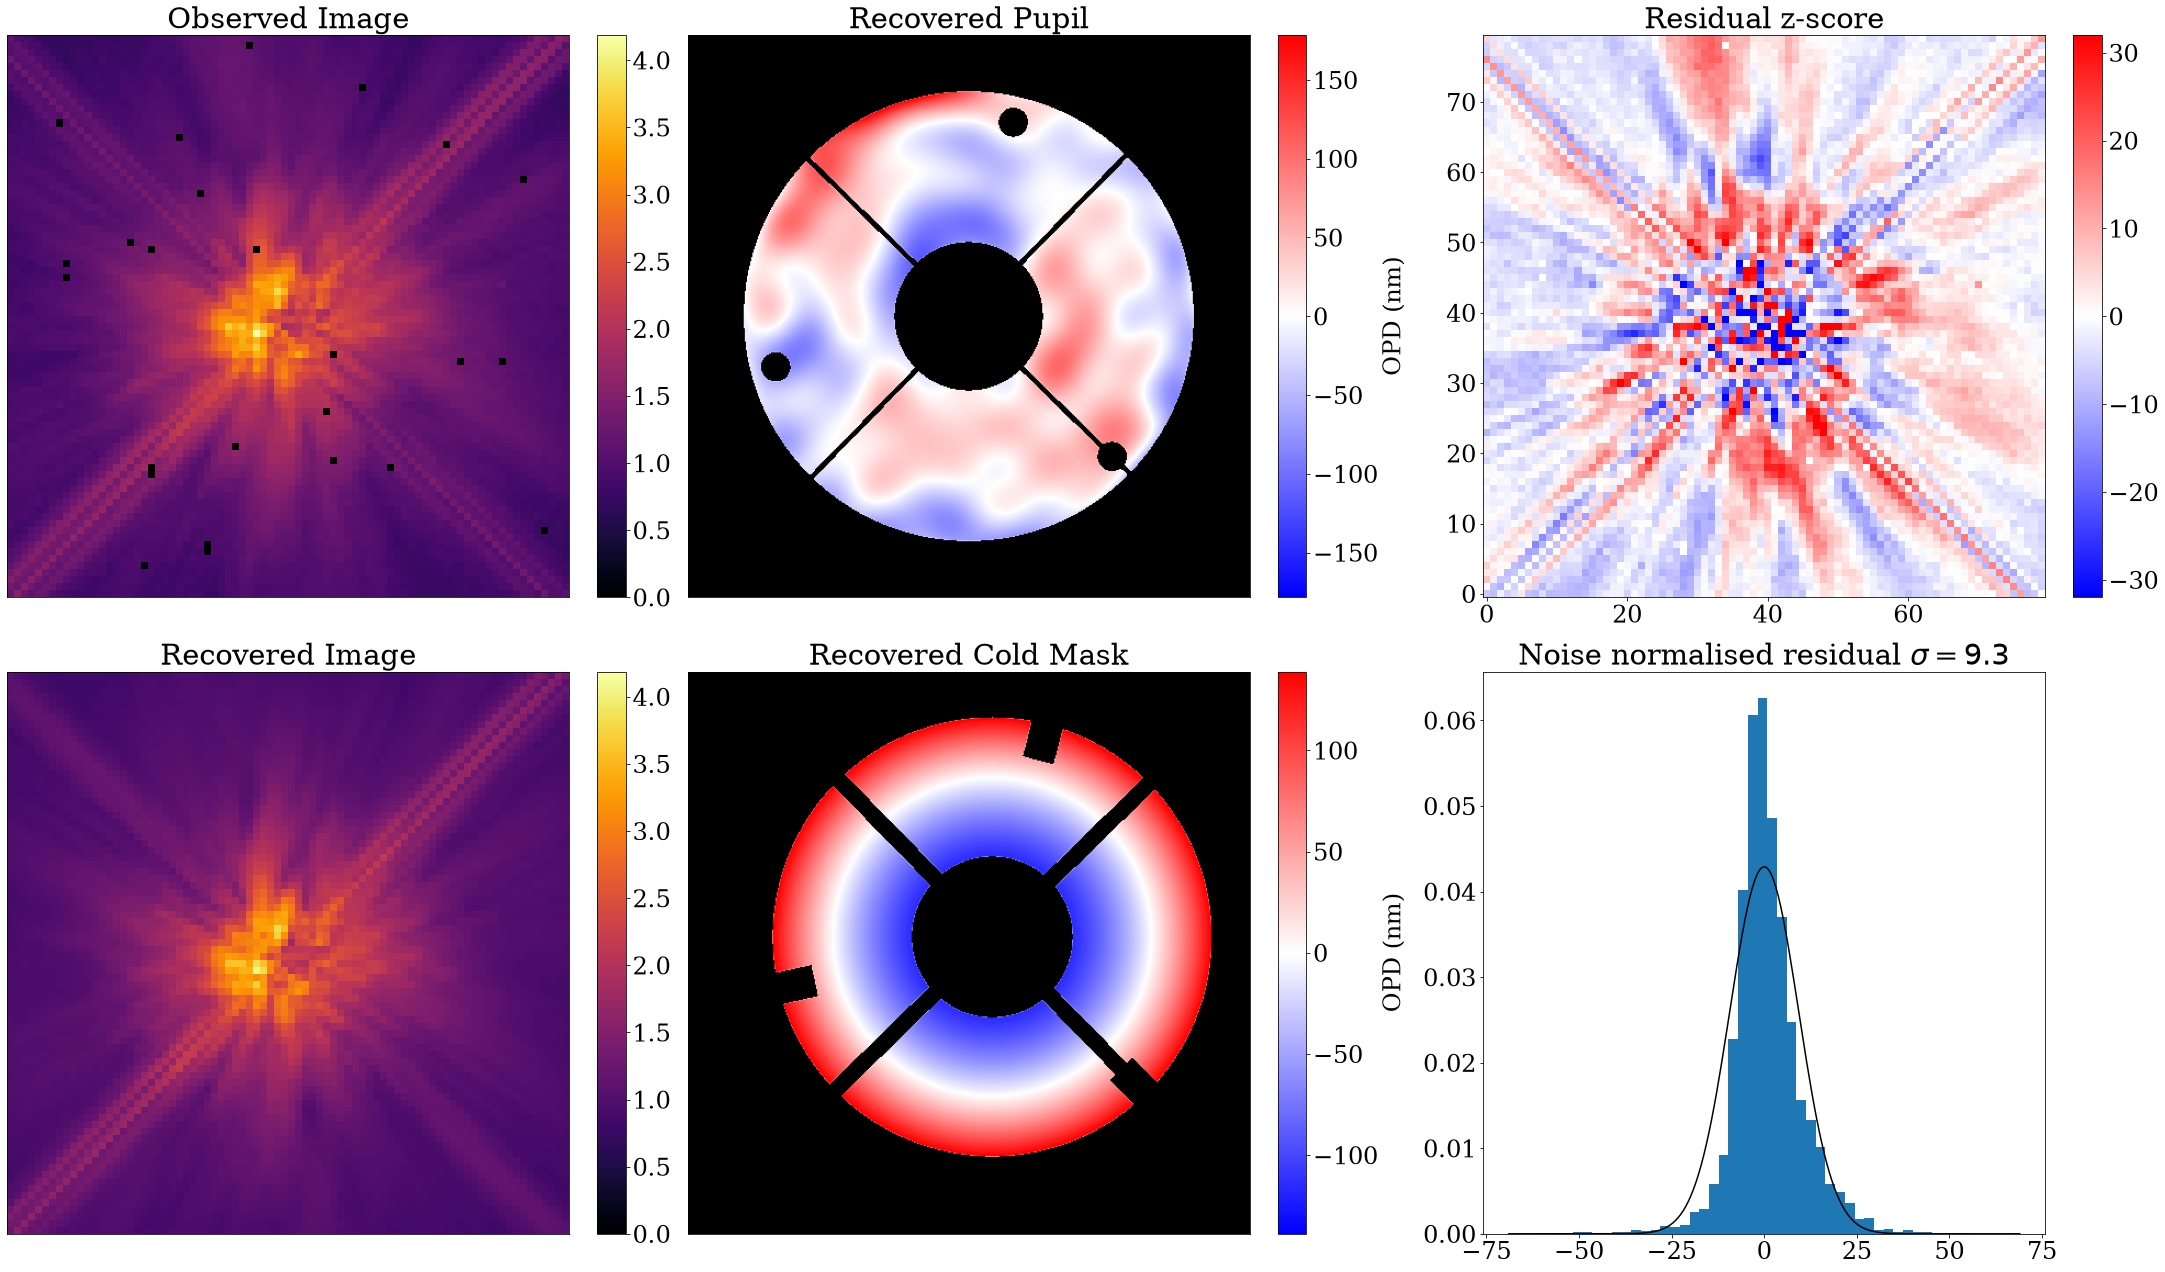

In [101]:
plot_params(params_history, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False, percentile=99)

In [102]:
params_history[-1]

{'bias': {'n8zu81fbq': Array(0.35306114, dtype=float64)},
 'cold_mask_opd': {'global': Array([89.80207559], dtype=float64)},
 'cold_mask_rot': {'global': Array(0.65410286, dtype=float64)},
 'cold_mask_shift': {'global': Array([12.56039931,  8.46851526], dtype=float64)},
 'cold_mask_tilt': {'global': Array([-0.01709669, -0.08644961], dtype=float64)},
 'primary_low': {'n8zu81fbq': Array([  3.59805947, -17.23473754,  -4.57465708,  23.28143587,
         -12.14232605,  -0.55231796,   1.66972235,  -7.90581101,
          -8.76997795,  -2.81185098,  -8.43517897,   0.86799458,
           1.73101889,  -1.52564586,  -1.30942126,  -6.77578229,
          -1.47699942,   4.52727936,   4.17587672,   5.88269215,
           2.7770425 ,   7.3103114 ,   7.86244931,  -0.38052116,
           4.33558922,   1.24943485,   0.95043359,   2.00986725,
           5.84288978,  -4.21817511], dtype=float64)},
 'primary_opd': {'global': Array([[  0.        ,  -2.51235248,   1.15569643,  -2.41211982,
            0.37737

In [103]:
np.save("params.npy", params_history[-1])